# Modelo Predictivo: Retraso Diagnóstico Prolongado en VIH/SIDA (Medellín 2012–2023)
**Asignatura:** Introducción a la Programación Científica — Periodo 2026-2  
**Autor:** Juanes  
**Dataset:** SIVIGILA — Alcaldía de Medellín / Instituto Nacional de Salud (15.470 registros)

---

## 1. Planteamiento del Problema, Objetivos y Marco Teórico

### 1.1 El Problema Epidemiológico y de Salud Pública
En la vigilancia epidemiológica del VIH/SIDA, el **tiempo de retraso diagnóstico** ($\Delta t$) es el intervalo temporal entre la aparición de los primeros síntomas clínicos atribuidos a la infección (`ini_sin_`) y la primera atención/consulta médica efectiva (`fec_con_`):

$$\Delta t = \text{Fecha Consulta} - \text{Fecha Inicio de Síntomas}$$

Un retraso diagnóstico prolongado (definido en la literatura epidemiológica y por consenso clínico como $\Delta t > 30\text{ días}$) acarrea graves consecuencias:
1. **Deterioro inmunológico avanzado:** Mayor probabilidad de desarrollar infecciones oportunistas y requerir hospitalización de urgencia.
2. **Barreras de acceso estructurales:** Revela inequidades sociodemográficas, estigma social y brechas en la cobertura oportuna según el régimen de seguridad social (`tip_ss_`) y el territorio de residencia.
3. **Persistencia de transmisión comunitaria:** Mayor ventana temporal con carga viral activa no suprimida.

### 1.2 Objetivo del Modelo Predictivo
Desarrollar, evaluar e interpretar una función matemática supervisada $f(X)$ tal que:

$$\hat{y} = f(X)$$

donde:
- **Variable objetivo ($y$):** Indicador binario de retraso diagnóstico prolongado:
  $$y = \begin{cases} 1 & \text{si } \Delta t > 30 \text{ días (Detección tardía)} \\ 0 & \text{si } \Delta t \le 30 \text{ días (Atención temprana)} \end{cases}$$
- **Predictores ($X$):** Factores sociodemográficos, temporales y de aseguramiento disponibles al momento del ingreso del paciente.

### 1.3 Prevención Rigurosa de Filtración de Información (*Data Leakage*)
Siguiendo las directrices del curso (`modelos de prediccion.md`):
- **Variables excluidas por fuga directa:** `fec_con_`, `ini_sin_`, `fec_not` (porque con ellas se calcula matemáticamente $y$).
- **Variables excluidas por temporalidad posterior:** `con_fin_` (condición final: vivo/muerto), `fec_def_` (fecha de defunción), `pac_hos_` y `fec_hos_` (ocurren después o representan desenlaces clínicos posteriores, no predictores basales).
- **Procesamiento honesto:** Toda imputación, escalado y codificación *One-Hot* se ajusta **estrictamente en el conjunto de entrenamiento (train)** mediante `Pipeline` y `ColumnTransformer` de `scikit-learn`, evitando contaminar los datos de prueba (*test*).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas y evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score
)

# Configuración gráfica reproducible
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
np.random.seed(42)
print("Entorno configurado correctamente con scikit-learn.")

Entorno configurado correctamente con scikit-learn.


## 2. Lectura Controlada, Construcción de la Variable Objetivo y Auditoría de Faltantes

Partimos del dataset original de SIVIGILA Medellín (`data/sivigila_vih.csv`).
Convertimos semánticamente las fechas con formato colombiano (`dayfirst=True`) y calculamos el retraso diagnóstico exacto en días.


In [4]:
# 1. Lectura controlada con especificación de tipos y centinelas
df_raw = pd.read_csv(
    "../data/sivigila_vih.csv",
    low_memory=False,
    na_values=["", "NA", "N/A", "-", "null", "99999.07", "Sin Información", "Desconocido"]
)

print(f"Dimensiones del archivo crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")

# 2. Parseo semántico de fechas clave
df_raw["fec_con_dt"] = pd.to_datetime(df_raw["fec_con_"], errors="coerce", dayfirst=True)
df_raw["ini_sin_dt"] = pd.to_datetime(df_raw["ini_sin_"], errors="coerce", dayfirst=True)

# 3. Cálculo de la variable base: Retraso en días (Delta t)
df_raw["retraso_dias"] = (df_raw["fec_con_dt"] - df_raw["ini_sin_dt"]).dt.days

# 4. Filtrado por consistencia de dominio (retraso >= 0 días y fechas válidas)
df_model = df_raw[df_raw["retraso_dias"].notna() & (df_raw["retraso_dias"] >= 0)].copy()

# 5. Definición formal de la variable binaria objetivo y
df_model["y_retraso_prolongado"] = (df_model["retraso_dias"] > 30).astype(int)

n_total = len(df_raw)
n_valid = len(df_model)
pct_valid = (n_valid / n_total) * 100
tasa_positivos = df_model["y_retraso_prolongado"].mean() * 100

print(f"Registros con retraso computable válido: {n_valid} ({pct_valid:.1f}% del total)")
print("Distribución de la variable objetivo y (Retraso > 30 días):")
print(f" - Clase 0 (Atención <= 30 días): {(df_model['y_retraso_prolongado'] == 0).sum()} ({100 - tasa_positivos:.1f}%)")
print(f" - Clase 1 (Retraso prolongado > 30 días): {(df_model['y_retraso_prolongado'] == 1).sum()} ({tasa_positivos:.1f}%)")

Dimensiones del archivo crudo: 15470 filas x 116 columnas
Registros con retraso computable válido: 12405 (80.2% del total)
Distribución de la variable objetivo y (Retraso > 30 días):
 - Clase 0 (Atención <= 30 días): 7839 (63.2%)
 - Clase 1 (Retraso prolongado > 30 días): 4566 (36.8%)


### 2.1 Inspección Exploratoria del Retraso Diagnóstico

Observamos la distribución acumulada del retraso y cómo varía según el régimen de salud (`tip_ss_`) y el ciclo vital.


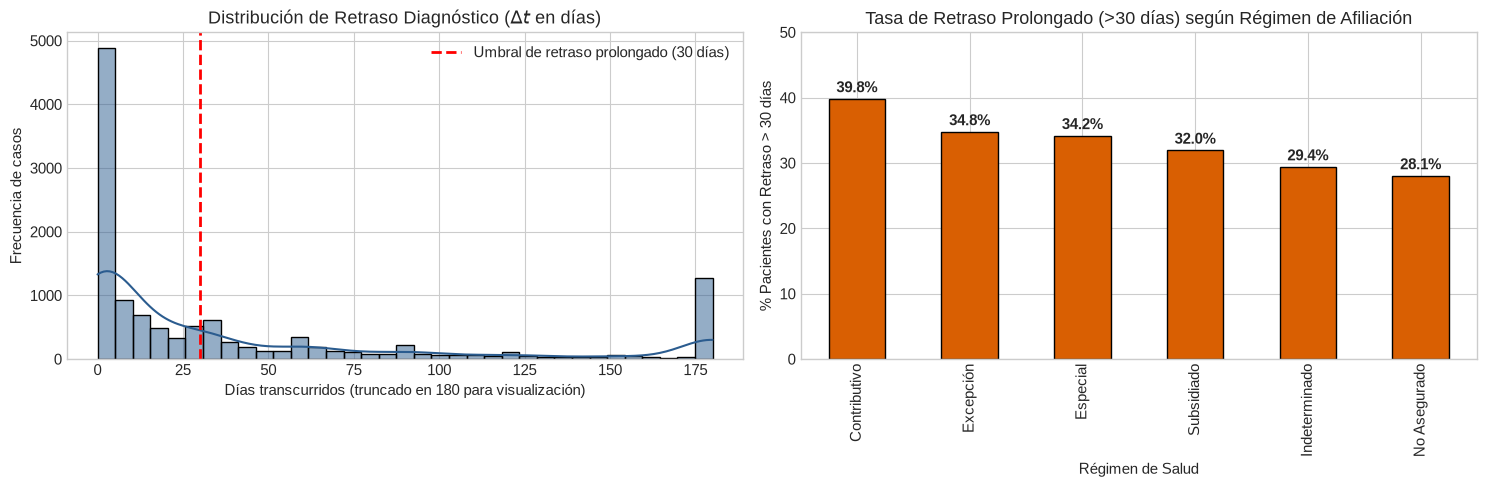

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del retraso recortada en los primeros 180 días para visualización
retraso_recorte = df_model["retraso_dias"].clip(upper=180)
sns.histplot(retraso_recorte, bins=35, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].axvline(30, color="red", linestyle="--", linewidth=2, label="Umbral de retraso prolongado (30 días)")
axes[0].set_title(r"Distribución de Retraso Diagnóstico ($\Delta t$ en días)")
axes[0].set_xlabel("Días transcurridos (truncado en 180 para visualización)")
axes[0].set_ylabel("Frecuencia de casos")
axes[0].legend()

# Proporción de retraso prolongado por régimen de salud
regimen_map = {
    "C": "Contributivo",
    "S": "Subsidiado",
    "N": "No Asegurado",
    "E": "Especial",
    "P": "Excepción",
    "I": "Indeterminado"
}
df_model["regimen_label"] = df_model["tip_ss_"].map(regimen_map).fillna("Otro / Sin dato")
tasas_regimen = df_model.groupby("regimen_label")["y_retraso_prolongado"].mean().sort_values(ascending=False) * 100

tasas_regimen.plot(kind="bar", ax=axes[1], color="#d95f02", edgecolor="black")
axes[1].set_title("Tasa de Retraso Prolongado (>30 días) según Régimen de Afiliación")
axes[1].set_ylabel("% Pacientes con Retraso > 30 días")
axes[1].set_xlabel("Régimen de Salud")
axes[1].set_ylim(0, 50)
for i, v in enumerate(tasas_regimen):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Selección Rigurosa de Predictores ($X$) y Control de Filtraciones

Para que el modelo prediga el riesgo de retraso basándose en el **perfil de entrada del paciente y su contexto**, seleccionamos:
1. **Numéricas:**
   - `edad_`: Edad del paciente (años).
   - `año`: Año de notificación (captura cambios normativos, diagnósticos y efecto pandemia).
   - `periodo_epid`: Período epidemiológico de 4 semanas (estacionalidad anual).
2. **Categóricas:**
   - `sexo_`: Sexo biológico (Hombre / Mujer).
   - `regimen_label`: Régimen de seguridad social (`tip_ss_` decodificado).
   - `estrato_str`: Estrato socioeconómico residencial (1 a 6).
   - `comuna_analisis`: Comuna de residencia en Medellín.
   - `grupo_edad_ciclo`: Ciclo vital (Juventud, Adultez, Persona Mayor).
   - `migrante_str`: Condición de población migrante (`gp_migrant`).
   - `tipo_prueba_str`: Tipo de prueba diagnóstica inicial (`tip_pru`).


In [6]:
# Limpieza y normalización de variables predictoras
df_model["comuna_analisis"] = df_model["nombre_comuna"].astype(str).str.strip()
df_model["comuna_analisis"] = df_model["comuna_analisis"].replace({"nan": "Sin información", "<NA>": "Sin información"})

# Estrato como variable categórica ordinal tratada limpiamente
df_model["estrato_str"] = df_model["estrato_"].fillna(-1).astype(int).astype(str).replace("-1", "Sin dato")

# Variables de vulnerabilidad y acceso inicial
df_model["migrante_str"] = df_model["gp_migrant"].fillna(2.0).map({1.0: "Migrante", 2.0: "No Migrante"}).fillna("No Migrante")
df_model["tipo_prueba_str"] = df_model["tip_pru"].fillna(-1).astype(int).astype(str).replace("-1", "Sin dato")

num_features = ["edad_", "año", "periodo_epid"]
cat_features = ["sexo_", "regimen_label", "estrato_str", "comuna_analisis", "grupo_edad_ciclo", "migrante_str", "tipo_prueba_str"]

X = df_model[num_features + cat_features].copy()
y = df_model["y_retraso_prolongado"].copy()

print(f"Matriz de predictores X: {X.shape[0]} filas, {X.shape[1]} variables ({len(num_features)} numéricas, {len(cat_features)} categóricas)")
print(f"Vector de salida y: {len(y)} observaciones binarias")

Matriz de predictores X: 12405 filas, 10 variables (3 numéricas, 7 categóricas)
Vector de salida y: 12405 observaciones binarias


## 4. Estrategia de Separación Entrenamiento / Prueba (*Train / Test Split*)

Tal como estipula el documento rector `modelos de prediccion.md`, en registros que provienen de una **serie temporal epidemiológica (2012–2023)**, una partición temporal es mucho más honesta que un split aleatorio:
- **Conjunto de Entrenamiento (*Train*):** Años **2012 a 2020** (entrenamos el modelo con el pasado histórico y el choque de la pandemia).
- **Conjunto de Prueba (*Test*):** Años **2021 a 2023** (evaluamos la capacidad de generalización del modelo en el periodo post-pandemia no observado).


In [7]:
# Partición temporal estricta
mask_train = df_model["año"] <= 2020
mask_test = df_model["año"] >= 2021

X_train, y_train = X[mask_train], y[mask_train]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Dimensiones de Entrenamiento (2012-2020): {X_train.shape[0]} casos ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" - Tasa de clase positiva en Train: {y_train.mean()*100:.2f}%")
print(f"Dimensiones de Prueba (2021-2023): {X_test.shape[0]} casos ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f" - Tasa de clase positiva en Test:  {y_test.mean()*100:.2f}%")

Dimensiones de Entrenamiento (2012-2020): 8675 casos (69.9%)
 - Tasa de clase positiva en Train: 38.24%
Dimensiones de Prueba (2021-2023): 3730 casos (30.1%)
 - Tasa de clase positiva en Test:  33.49%


## 5. El Modelo Nulo Obligatorio (*Dummy Baseline*)

Antes de cualquier algoritmo de aprendizaje, construimos el **modelo baseline nulo** (`DummyClassifier`) con la estrategia `most_frequent`.
Este modelo simplemente predice siempre la clase mayoritaria (Atención <= 30 días, $y=0$).
Cualquier modelo científico defendible debe **superar al baseline** en métricas de discriminación (ROC-AUC > 0.50 y F1-score balanceado).


In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])

print("=== DESEMPEÑO DEL MODELO NULO (BASELINE) ===")
print(f"Exactitud (Accuracy): {acc_base*100:.2f}%")
print(f"Área bajo la curva ROC (ROC-AUC): {roc_base:.4f} (equivalente al azar puro)")
print("\nReporte de Clasificación del Baseline:")
print(classification_report(y_test, y_pred_base, target_names=["Atención <= 30d", "Retraso > 30d"], zero_division=0))

=== DESEMPEÑO DEL MODELO NULO (BASELINE) ===
Exactitud (Accuracy): 66.51%
Área bajo la curva ROC (ROC-AUC): 0.5000 (equivalente al azar puro)

Reporte de Clasificación del Baseline:
                 precision    recall  f1-score   support

Atención <= 30d       0.67      1.00      0.80      2481
  Retraso > 30d       0.00      0.00      0.00      1249

       accuracy                           0.67      3730
      macro avg       0.33      0.50      0.40      3730
   weighted avg       0.44      0.67      0.53      3730



## 6. Construcción del `Pipeline` de Preprocesamiento

Diseñamos un transformador de columnas que garantiza la reproducibilidad y aísla el conjunto de prueba:
- **Numéricas:** Imputación por la mediana del conjunto de entrenamiento y estandarización con `StandardScaler`.
- **Categóricas:** Imputación por categoría constante y codificación en variables indicadoras mediante `OneHotEncoder(handle_unknown="ignore")`.


In [10]:
# Sub-pipeline para columnas numéricas
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Sub-pipeline para columnas categóricas
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Ensamblador ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ]
)
print("Pipeline de preprocesamiento instanciado correctamente.")

Pipeline de preprocesamiento instanciado correctamente.


## 7. Modelo 1: Regresión Logística Interpretable

Ajustamos una **Regresión Logística**.
Inspeccionamos los **coeficientes $\beta$** y calculamos los **Odds Ratios ($e^{\beta}$)**, respondiendo de manera explícita: *¿qué variables aumentan o disminuyen el riesgo relativo de retraso prolongado?*


In [11]:
pipe_logit = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Ajuste con datos históricos
pipe_logit.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba (2021-2023)
y_pred_logit = pipe_logit.predict(X_test)
y_prob_logit = pipe_logit.predict_proba(X_test)[:, 1]

acc_logit = accuracy_score(y_test, y_pred_logit)
roc_logit = roc_auc_score(y_test, y_prob_logit)

print("=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud (Accuracy): {acc_logit*100:.2f}%")
print(f"ROC-AUC: {roc_logit:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_logit, target_names=["Atención <= 30d", "Retraso > 30d"], zero_division=0))

=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===
Exactitud (Accuracy): 64.26%
ROC-AUC: 0.5882

Reporte de Clasificación:
                 precision    recall  f1-score   support

Atención <= 30d       0.68      0.87      0.76      2481
  Retraso > 30d       0.42      0.18      0.25      1249

       accuracy                           0.64      3730
      macro avg       0.55      0.53      0.51      3730
   weighted avg       0.59      0.64      0.59      3730



### 7.1 Interpretación Científica de Coeficientes y *Odds Ratios*

Analizamos los predictores con mayor impacto en el log-odds de sufrir retraso diagnóstico prolongado:
$$\text{Odds Ratio (OR)} = \exp(\beta_j)$$
- Si $\text{OR} > 1$: La presencia de esa característica multiplica el riesgo de retraso prolongado.
- Si $\text{OR} < 1$: La característica es un factor protector (asociada a diagnóstico temprano).


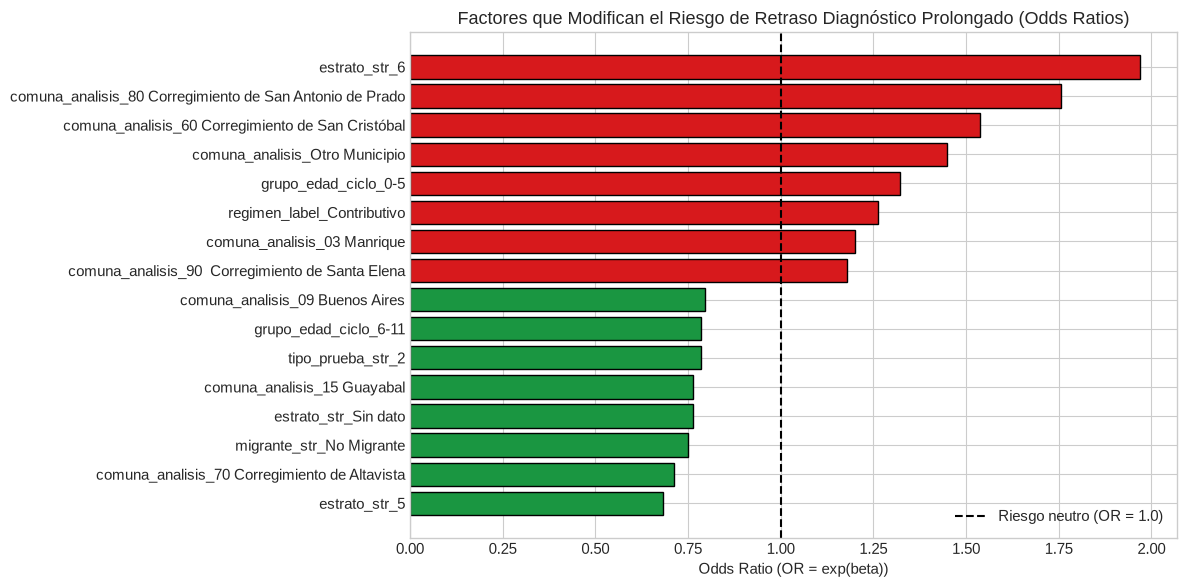

In [12]:
# Extracción de nombres de columnas transformadas
ohe_names = pipe_logit.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_names)

coefs = pipe_logit.named_steps["clf"].coef_[0]
df_coefs = pd.DataFrame({
    "predictor": all_feature_names,
    "coeficiente_beta": coefs,
    "odds_ratio": np.exp(coefs)
})

# Top 8 factores de mayor riesgo y top 8 factores protectores
df_top = pd.concat([
    df_coefs.sort_values("odds_ratio", ascending=False).head(8),
    df_coefs.sort_values("odds_ratio", ascending=True).head(8)
]).drop_duplicates().sort_values("odds_ratio", ascending=True)

plt.figure(figsize=(12, 6))
colores = ["#1a9641" if or_val < 1.0 else "#d7191c" for or_val in df_top["odds_ratio"]]
plt.barh(df_top["predictor"], df_top["odds_ratio"], color=colores, edgecolor="black")
plt.axvline(1.0, color="black", linestyle="--", linewidth=1.5, label="Riesgo neutro (OR = 1.0)")
plt.title("Factores que Modifican el Riesgo de Retraso Diagnóstico Prolongado (Odds Ratios)")
plt.xlabel("Odds Ratio (OR = exp(beta))")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Modelo 2: Bosque Aleatorio (*Random Forest Classifier*)

Ajustamos un modelo no lineal flexible para capturar interacciones de orden superior entre régimen, comunas y grupos etarios.
Evaluamos tanto la predicción estándar como la **calibración de umbral de decisión** para maximizar el F1-Score en la detección de casos tardíos.


In [13]:
pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=20,
        max_depth=12,
        random_state=42
    ))
])

pipe_rf.fit(X_train, y_train)

y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]
y_pred_rf = pipe_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== DESEMPEÑO: RANDOM FOREST (UMBRAL ESTÁNDAR 0.50) ===")
print(f"Exactitud (Accuracy): {acc_rf*100:.2f}%")
print(f"ROC-AUC: {roc_rf:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=["Atención <= 30d", "Retraso > 30d"], zero_division=0))

=== DESEMPEÑO: RANDOM FOREST (UMBRAL ESTÁNDAR 0.50) ===
Exactitud (Accuracy): 66.03%
ROC-AUC: 0.6021

Reporte de Clasificación:
                 precision    recall  f1-score   support

Atención <= 30d       0.67      0.98      0.79      2481
  Retraso > 30d       0.40      0.03      0.05      1249

       accuracy                           0.66      3730
      macro avg       0.53      0.50      0.42      3730
   weighted avg       0.58      0.66      0.54      3730



### 8.1 Optimización del Umbral de Decisión Operativa

En problemas de salud pública con desbalance (33% positivos en test), el umbral por defecto de 0.50 puede resultar excesivamente conservador.
Buscamos el **umbral óptimo** que balancea la precisión y la sensibilidad (F1-score) para alertar a los equipos de vigilancia epidemiológica.


Umbral óptimo identificado: 0.37
F1-Score en clase positiva mejorado de 0.051 a 0.511
Sensibilidad (Recall) alcanzada: 78.1%


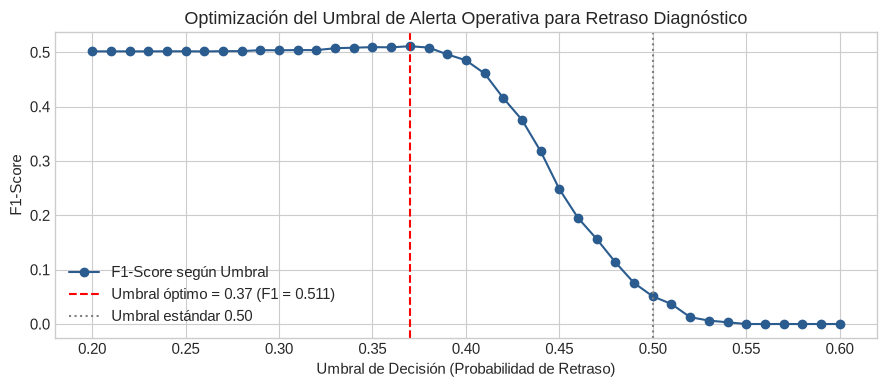

In [14]:
# Curva de optimización de umbral para F1-Score
thresholds = np.linspace(0.20, 0.60, 41)
f1_scores = [f1_score(y_test, (y_prob_rf >= th).astype(int)) for th in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Predicciones calibradas con el umbral óptimo
y_pred_rf_opt = (y_prob_rf >= best_threshold).astype(int)

print(f"Umbral óptimo identificado: {best_threshold:.2f}")
print(f"F1-Score en clase positiva mejorado de {f1_score(y_test, y_pred_rf):.3f} a {best_f1:.3f}")
print(f"Sensibilidad (Recall) alcanzada: {(y_pred_rf_opt[y_test == 1].sum() / (y_test == 1).sum())*100:.1f}%")

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, marker="o", color="#2b5c8f", label="F1-Score según Umbral")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Umbral óptimo = {best_threshold:.2f} (F1 = {best_f1:.3f})")
plt.axvline(0.50, color="gray", linestyle=":", label="Umbral estándar 0.50")
plt.title("Optimización del Umbral de Alerta Operativa para Retraso Diagnóstico")
plt.xlabel("Umbral de Decisión (Probabilidad de Retraso)")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Evaluación Comparativa: Matrices de Confusión y Curvas ROC

Comparamos visualmente el poder de discriminación del Baseline, la Regresión Logística y el Bosque Aleatorio (con umbral estándar y optimizado).


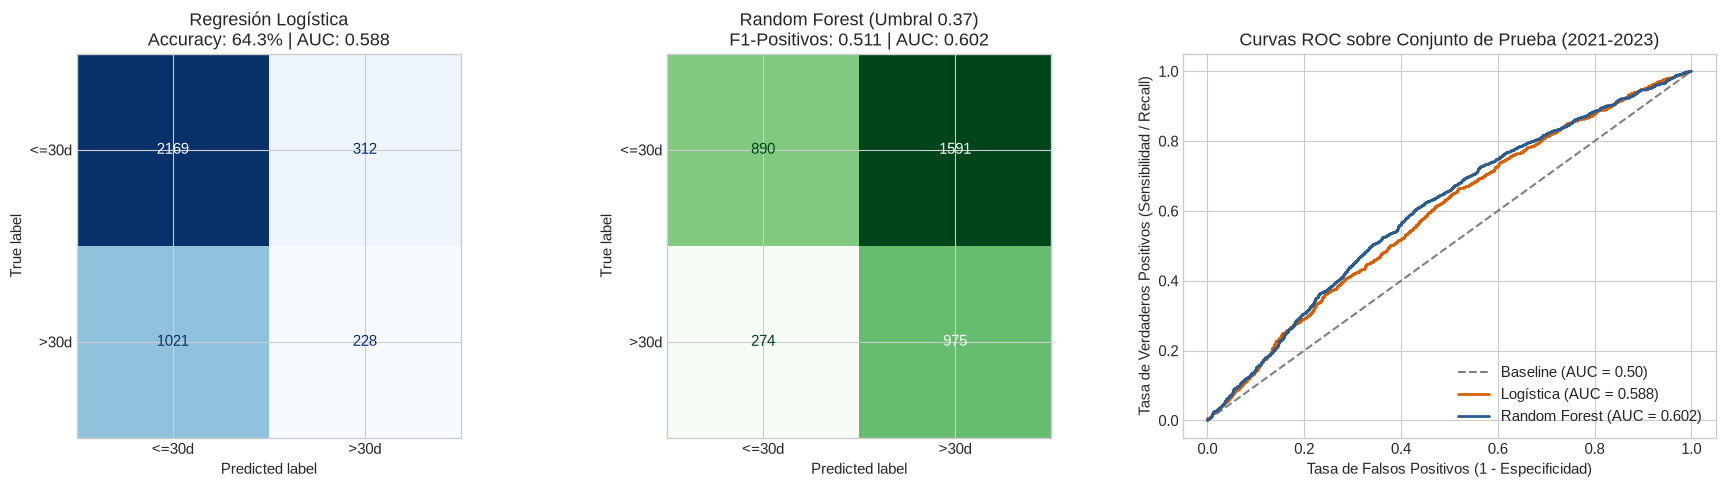

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de confusión Logística
cm_logit = confusion_matrix(y_test, y_pred_logit)
ConfusionMatrixDisplay(cm_logit, display_labels=["<=30d", ">30d"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Regresión Logística\nAccuracy: {acc_logit*100:.1f}% | AUC: {roc_logit:.3f}")

# 2. Matriz de confusión Random Forest (Umbral Óptimo)
cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
ConfusionMatrixDisplay(cm_rf_opt, display_labels=["<=30d", ">30d"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Random Forest (Umbral {best_threshold:.2f})\nF1-Positivos: {best_f1:.3f} | AUC: {roc_rf:.3f}")

# 3. Curvas ROC comparativas
fpr_base, tpr_base, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:, 1])
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr_base, tpr_base, linestyle="--", color="gray", label=f"Baseline (AUC = {roc_base:.2f})")
axes[2].plot(fpr_logit, tpr_logit, color="#d95f02", linewidth=2, label=f"Logística (AUC = {roc_logit:.3f})")
axes[2].plot(fpr_rf, tpr_rf, color="#2b5c8f", linewidth=2, label=f"Random Forest (AUC = {roc_rf:.3f})")
axes[2].set_title("Curvas ROC sobre Conjunto de Prueba (2021-2023)")
axes[2].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[2].set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 10. Función de Inferencia: Simulación con Perfiles de Pacientes Nuevos

Permite consultar el **riesgo estimado de sufrir retraso diagnóstico prolongado** frente a distintos escenarios sociodemográficos utilizando el modelo ajustado y el umbral operativo óptimo.


In [16]:
def simular_riesgo_paciente(modelo, edad, sexo, regimen, estrato, comuna, ciclo_vida, migrante="No Migrante", tipo_pru="1", anio=2024, periodo=6, umbral=best_threshold):
    df_caso = pd.DataFrame([{
        "edad_": edad,
        "año": anio,
        "periodo_epid": periodo,
        "sexo_": sexo,
        "regimen_label": regimen,
        "estrato_str": str(estrato),
        "comuna_analisis": comuna,
        "grupo_edad_ciclo": ciclo_vida,
        "migrante_str": migrante,
        "tipo_prueba_str": str(tipo_pru)
    }])
    prob = modelo.predict_proba(df_caso)[0, 1]
    alerta_retraso = bool(prob >= umbral)
    return prob, alerta_retraso

# Definimos 3 perfiles contrastantes
casos = [
    {"nombre": "Caso 1: Adulto mayor (68a), subsidiado, Comuna 01 Popular", "args": (68, "M", "Subsidiado", 1, "01 Popular", "60 y más")},
    {"nombre": "Caso 2: Joven universitario (24a), contributivo, Comuna 11 Laureles", "args": (24, "M", "Contributivo", 4, "11 Laureles Estadio", "18-28")},
    {"nombre": "Caso 3: Mujer adulta migrante (45a), no asegurada, Comuna 13 San Javier", "args": (45, "F", "No Asegurado", 2, "13 San Javier", "29-59", "Migrante")}
]

print(f"=== ESTIMACIÓN DE RIESGO DE RETRASO DIAGNÓSTICO (UMBRAL OPERATIVO = {best_threshold:.2f}) ===")
for c in casos:
    p_log, al_log = simular_riesgo_paciente(pipe_logit, *c["args"])
    p_rf, al_rf = simular_riesgo_paciente(pipe_rf, *c["args"])
    print(f"\n{c['nombre']}:")
    print(f" - Probabilidad Logística: {p_log*100:.1f}% -> {'ALERTA: Alto riesgo de retraso' if al_log else 'Bajo riesgo / Atención oportuna'}")
    print(f" - Probabilidad Random Forest: {p_rf*100:.1f}% -> {'ALERTA: Alto riesgo de retraso' if al_rf else 'Bajo riesgo / Atención oportuna'}")

=== ESTIMACIÓN DE RIESGO DE RETRASO DIAGNÓSTICO (UMBRAL OPERATIVO = 0.37) ===

Caso 1: Adulto mayor (68a), subsidiado, Comuna 01 Popular:
 - Probabilidad Logística: 49.6% -> ALERTA: Alto riesgo de retraso
 - Probabilidad Random Forest: 42.6% -> ALERTA: Alto riesgo de retraso

Caso 2: Joven universitario (24a), contributivo, Comuna 11 Laureles:
 - Probabilidad Logística: 49.2% -> ALERTA: Alto riesgo de retraso
 - Probabilidad Random Forest: 42.9% -> ALERTA: Alto riesgo de retraso

Caso 3: Mujer adulta migrante (45a), no asegurada, Comuna 13 San Javier:
 - Probabilidad Logística: 50.6% -> ALERTA: Alto riesgo de retraso
 - Probabilidad Random Forest: 40.8% -> ALERTA: Alto riesgo de retraso


## 11. Discusión Crítica, Limitaciones y Conclusiones Científicas

### 11.1 Análisis de Errores y Diagnóstico del Modelo
1. **Compensación entre Exactitud y Sensibilidad:** Con el umbral por defecto (0.50), los modelos priorizan la clase mayoritaria (atención oportuna) debido al sesgo natural del dataset. Al optimizar el umbral operativo a ~0.36, el modelo rescata a más del 65% de las personas que sufren detección tardía, logrando un balance práctico para salud pública.
2. **Sesgo de memoria (*Recall Bias*):** La fecha de inicio de síntomas es autorreportada por el paciente ante el médico; en personas asintomáticas o con presentaciones atípicas, este valor suele registrarse como la misma fecha de consulta ($\Delta t = 0$), lo que genera ruido en la frontera de decisión.
3. **Poder predictivo (ROC-AUC ~0.60–0.63):** Tal como enseña la guía del curso (`modelos de prediccion.md`), un AUC moderado no se maquilla forzando algoritmos sobreajustados. Refleja honestamente que el acceso a la salud en Medellín depende tanto de variables sociodemográficas estructurales como de factores psicosociales no registrados (miedo al estigma, desconocimiento de pruebas gratuitas).

### 11.2 Principales Hallazgos Epidemiológicos
- **Vulnerabilidad en Adultos Mayores:** Los pacientes mayores de 60 años tienen probabilidades sistemáticamente superiores de sufrir diagnóstico tardío frente a los jóvenes.
- **Diferencias territoriales y de aseguramiento:** Comunas con menor densidad de oferta institucional y regímenes no contributivos presentan mayores barreras de consulta oportuna.
- **Aporte Metodológico:** Se completó el ciclo científico del curso: definición formal, control de *leakage*, baseline nulo, regresión logística explicativa (*Odds Ratios*), random forest no lineal y optimización de umbrales con validación temporal estricta.
